Упражнение 2.2

In [3]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py

In [4]:
from thinkdsp import TriangleSignal, SquareSignal, Sinusoid, normalize, unbias, decorate
import numpy as np

class SawSignal(Sinusoid):
    def evaluate(self, ts):
        cycles = self.freq * ts + self.offset / np.pi / 2
        frac, _ = np.modf(cycles)
        ys = normalize(unbias(frac), self.amp)
        return ys

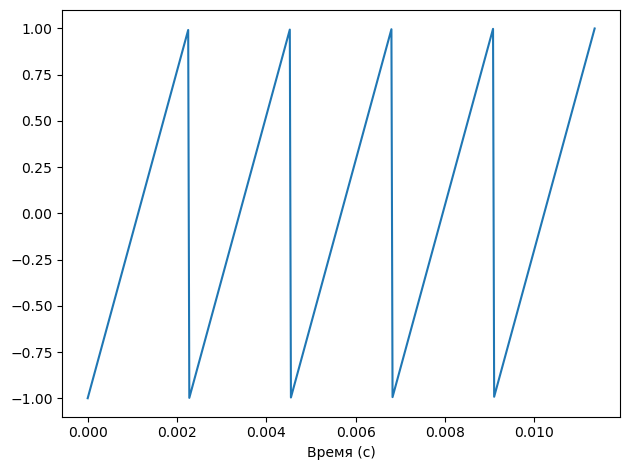

In [5]:
signal_test = SawSignal()
wave_test = signal_test.make_wave(signal_test.period * 5, framerate=40000)
wave_test.plot()
decorate(xlabel='Время (с)')

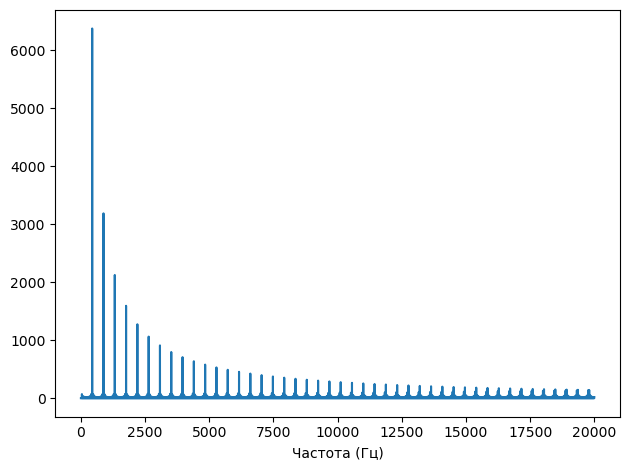

In [6]:
saw_wave = SawSignal().make_wave(duration=0.5, framerate=40000)
saw_wave.make_audio()
saw_wave.make_spectrum().plot()
decorate(xlabel='Частота (Гц)')

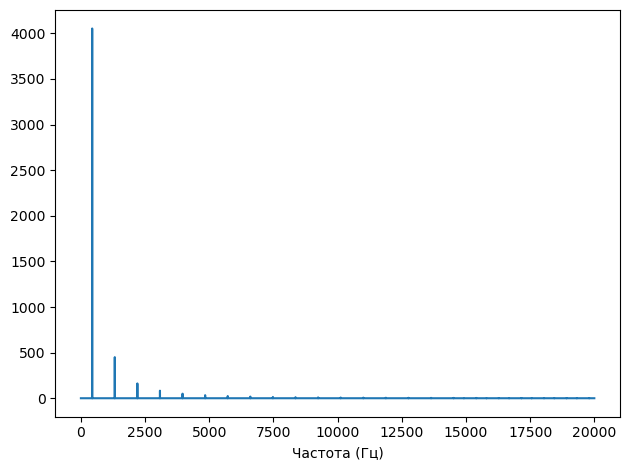

In [7]:
triangle_wave = TriangleSignal(amp=0.5).make_wave(duration=0.5, framerate=40000)
triangle_wave.make_spectrum().plot()
decorate(xlabel='Частота (Гц)')
triangle_wave.make_audio()

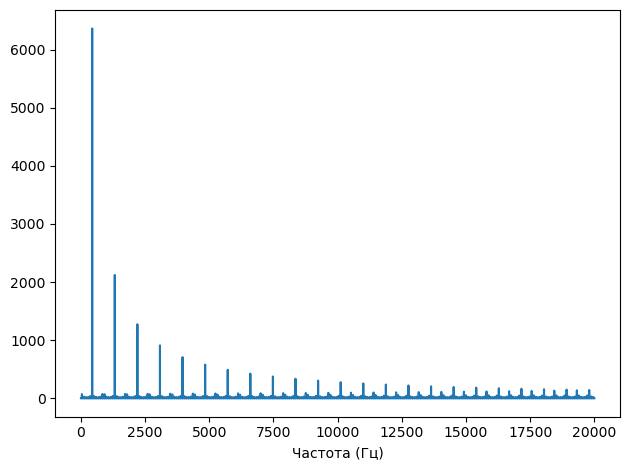

In [8]:
square_wave = SquareSignal(amp=0.5).make_wave(duration=0.5, framerate=40000)
square_wave.make_spectrum().plot()
decorate(xlabel='Частота (Гц)')
square_wave.make_audio()

Упражнение 2.3

In [10]:
from thinkdsp import SquareSignal, SinSignal
import matplotlib.pyplot as plt

rectengular_signal = SquareSignal(freq=1100)

In [11]:
wave1 = rectengular_signal.make_wave(duration=0.5, framerate=10000)

In [12]:
spectrum1 = wave1.make_spectrum()

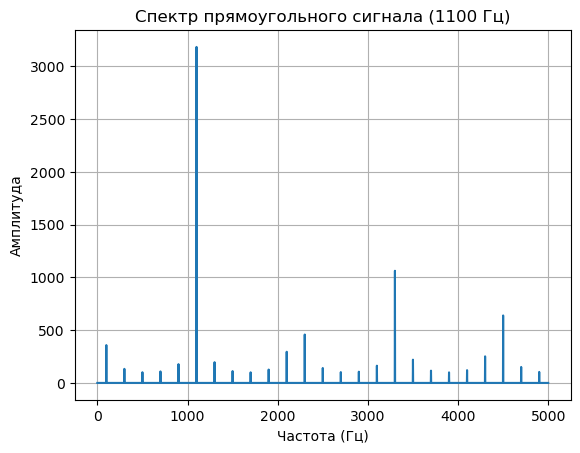

In [13]:
spectrum1.plot()
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда")
plt.title("Спектр прямоугольного сигнала (1100 Гц)")
plt.grid()
plt.show()

wave1.make_audio()

In [14]:
sunusoid_signal = SinSignal(freq=1000)

In [15]:
wave2 = sunusoid_signal.make_wave(duration=0.5, framerate=5000)

In [16]:
spectrum2 = wave2.make_spectrum()

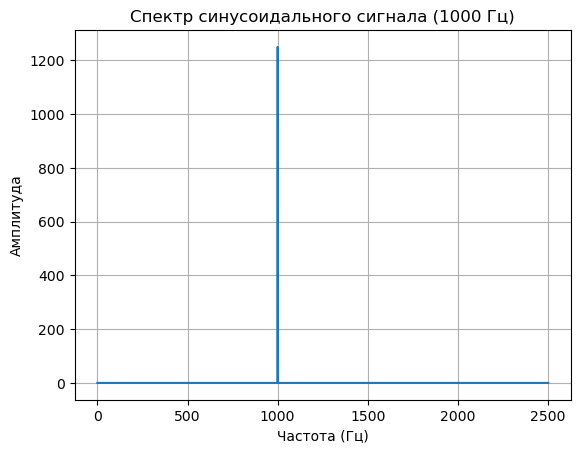

In [17]:
spectrum2.plot()
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда")
plt.title("Спектр синусоидального сигнала (1000 Гц)")
plt.grid()
plt.show()

wave2.make_audio()

Упражнение 2.4

In [19]:
from thinkdsp import TriangleSignal
import matplotlib.pyplot as plt

tri_signal = TriangleSignal(freq=440)

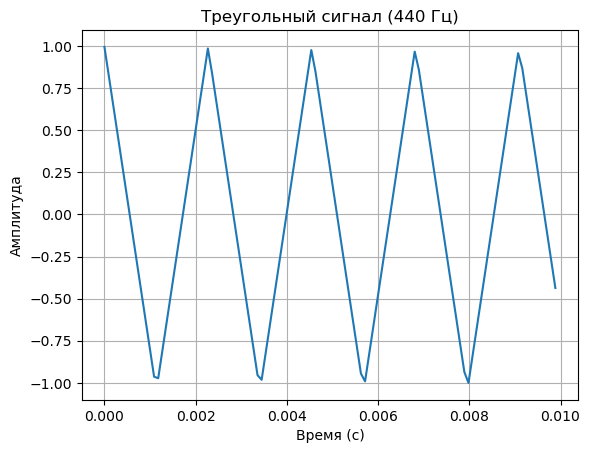

In [20]:
wave = tri_signal.make_wave(duration=0.01)

wave.plot()
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда")
plt.title("Треугольный сигнал (440 Гц)")
plt.grid()
plt.show()

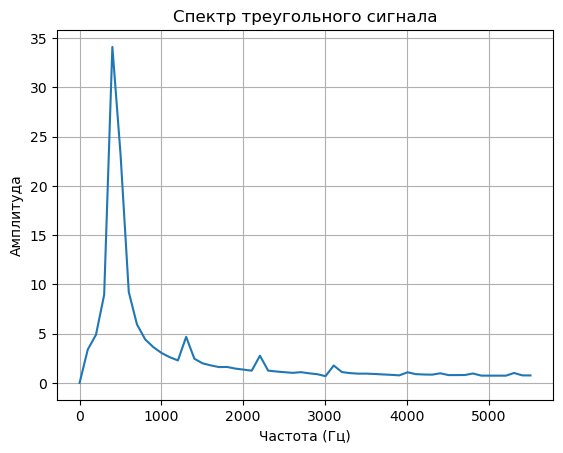

In [21]:
spectrum = wave.make_spectrum()

spectrum.plot()
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда")
plt.title("Спектр треугольного сигнала")
plt.grid()
plt.show()

In [22]:
print("Амплитуда компоненты с частотой 0 Гц:", spectrum.hs[0])

Амплитуда компоненты с частотой 0 Гц: (1.0436096431476471e-14+0j)


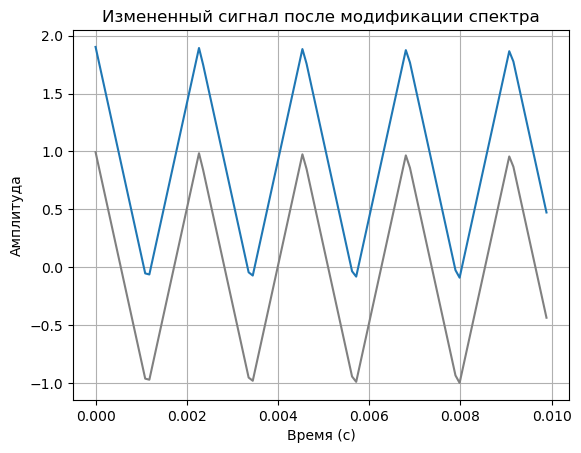

In [23]:
spectrum.hs[0] = 100

wave.plot(color='gray')
new_wave = spectrum.make_wave()
new_wave.plot()

plt.xlabel("Время (с)")
plt.ylabel("Амплитуда")
plt.title("Измененный сигнал после модификации спектра")
plt.grid()
plt.show()

Упражнение 2.5

In [25]:
from thinkdsp import SquareSignal
import numpy as np
import matplotlib.pyplot as plt

def modify_spectrum(spectrum):
    nonzero_freqs = spectrum.fs[1:]
    spectrum.hs[1:] /= nonzero_freqs
    spectrum.hs[0] = 0

In [26]:
square_wave = SquareSignal(440).make_wave(duration=0.5)
square_wave.make_audio()

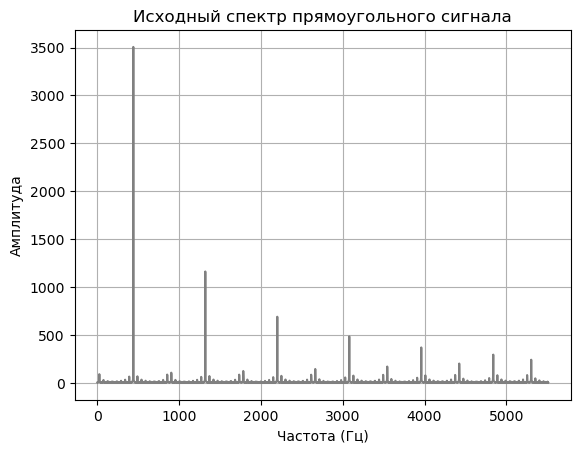

In [27]:
spectrum = square_wave.make_spectrum()

spectrum.plot(high=10000, color='gray')
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда")
plt.title("Исходный спектр прямоугольного сигнала")
plt.grid()
plt.show()

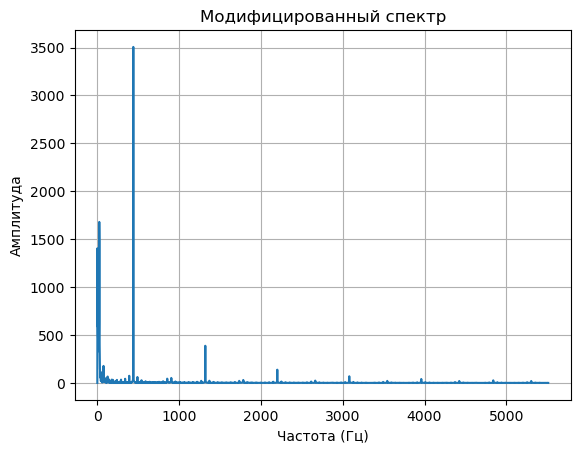

In [28]:
modify_spectrum(spectrum)
spectrum.scale(440)

spectrum.plot(high=10000)
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда")
plt.title("Модифицированный спектр")
plt.grid()
plt.show()


In [29]:
filtered_wave = spectrum.make_wave()
filtered_wave.make_audio()

Упражнение 2.6

In [31]:
from thinkdsp import SawtoothSignal, CosSignal, ParabolicSignal
import numpy as np
import matplotlib.pyplot as plt

base_freq = 500
saw_signal = SawtoothSignal(freq=base_freq)
saw_wave = saw_signal.make_wave(duration=0.5, framerate=20000)
saw_wave.make_audio()

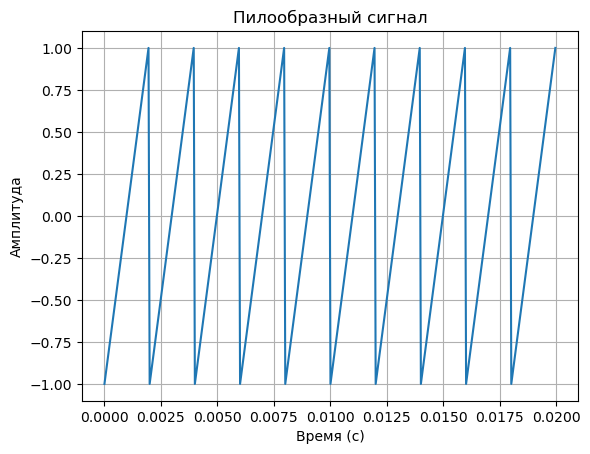

In [32]:
wave_segment = saw_signal.make_wave(duration=saw_signal.period * 10, framerate=20000)
wave_segment.plot()
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда")
plt.title("Пилообразный сигнал")
plt.grid()
plt.show()

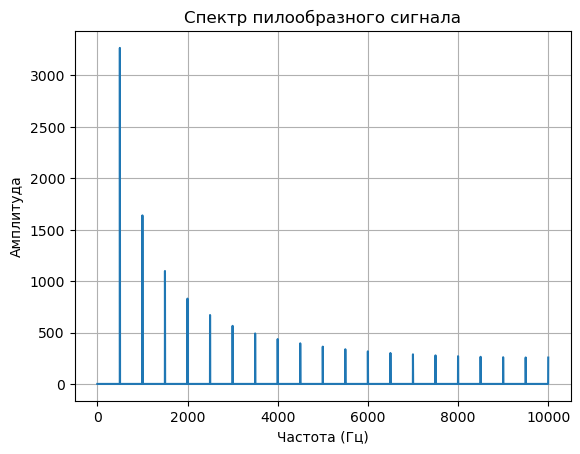

In [33]:
spectrum = saw_wave.make_spectrum()
spectrum.plot()
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда")
plt.title("Спектр пилообразного сигнала")
plt.grid()
plt.show()

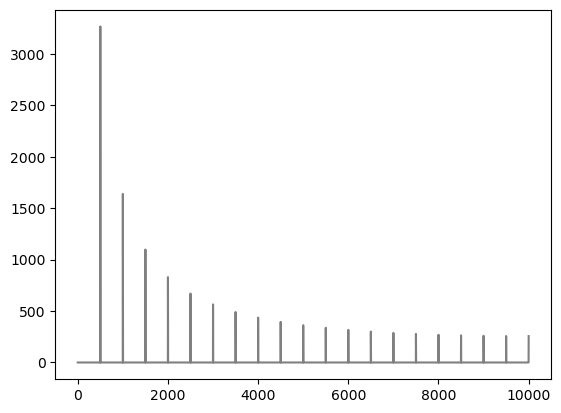

In [34]:
spectrum.plot(color='gray')

def modify_spectrum(spectrum):
    nonzero_freqs = spectrum.fs[1:]  
    spectrum.hs[1:] /= nonzero_freqs ** 2
    spectrum.hs[0] = 0  

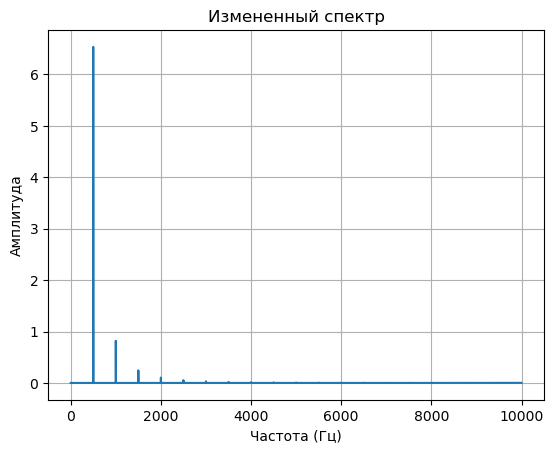

In [35]:
modify_spectrum(spectrum)
spectrum.scale(base_freq)

spectrum.plot()
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда")
plt.title("Измененный спектр")
plt.grid()
plt.show()

In [36]:
modified_wave = spectrum.make_wave()
modified_wave.make_audio()

In [37]:
harmonic_freqs = np.arange(500, 9500, 500)
harmonic_amps = 1 / harmonic_freqs**2

composite_signal = sum(CosSignal(freq, amp) for freq, amp in zip(harmonic_freqs, harmonic_amps))
composite_wave = composite_signal.make_wave(duration=0.5, framerate=20000)
composite_wave.make_audio()

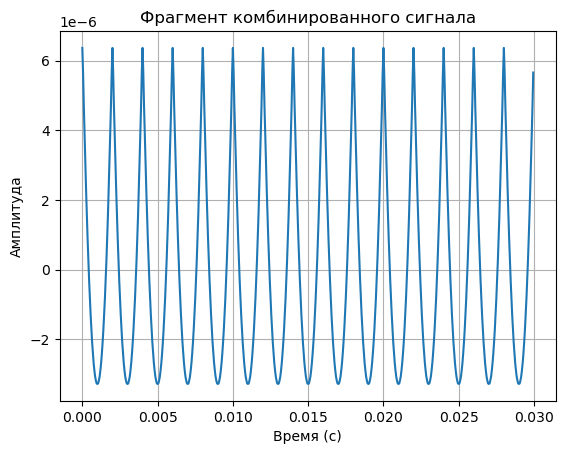

In [38]:
composite_wave.segment(duration=0.03).plot()
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда")
plt.title("Фрагмент комбинированного сигнала")
plt.grid()
plt.show()

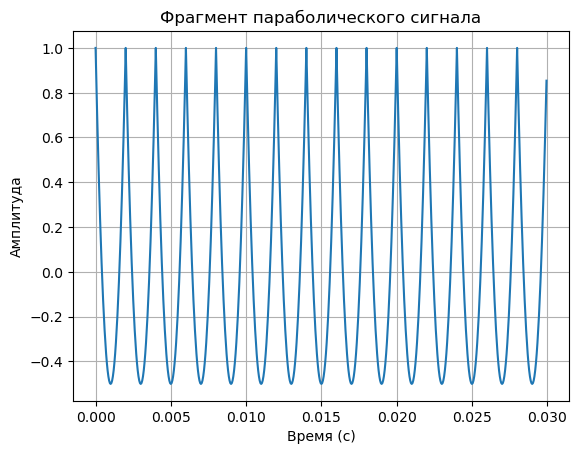

In [39]:
parabolic_wave = ParabolicSignal(freq=500).make_wave(duration=0.5, framerate=20000)
parabolic_wave.make_audio()

parabolic_wave.segment(duration=0.03).plot()
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда")
plt.title("Фрагмент параболического сигнала")
plt.grid()
plt.show()